In [17]:
# !/usr/bin/env python3 
# executable - set up paths for import
import os
import sys
# to setup import paths add project root dir to sys.path (with baseVR dir in it)
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
from baseVR.base_functionality import init_import_paths
init_import_paths()

# Auto-reload modules before executing code
%load_ext autoreload
%autoreload 2

from dashsrc.plot_components.plots import plot_unit_fr_stability
from dashsrc.plot_components.plots import plot_EnsambleEncondings
from analytics_processing import analytics
import analytics_processing.analytics_constants as C
from CustomLogger import CustomLogger as Logger
from analytics_processing.modality_loading import session_modality_from_nas
from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args
from analytics_processing.sessions_from_nas_parsing import fullfnames2snames


from dashsrc.plot_components.plots import plot_SessionWaveforms
from dashsrc.plot_components.plots import plot_EnsembleChoiceEncoding
from dashsrc.plot_components.plot_wrappers.data_selection import group_filter_data

from dashsrc.plot_components.plots import plot_adc_bias


output_dir = "/mnt/SpatialSequenceLearning/Simon/fr_stability/"
data = {}
nas_dir = C.device_paths()[0]
Logger().init_logger(None, None, logging_level="WARNING")

import plotly.io as pio



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
                                                        # 1 2 
# 3,4,5,6,7,8,9,10,11,12,13,14,
# animal_ids = [6]
animal_ids = [10]
# session_ids = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30]
# session_ids = [5,6,7,8,9,10]
# session_ids = [11,12,13,14,]
# session_ids = [15,16,17,18,19,20,21,22,23,24,25,26]
# session_ids = None
session_ids = None
paradigm_ids = [0, 1100]
# excl_session_names = ['2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min', '2025-01-21_18-49_rYL006_P1100_LinearTrackStop_30min', '2024-12-11_17-42_rYL006_P1100_LinearTrackStop_30min']
excl_session_names = None
# cols = ["session_spike_count", "session_nsamples", "cluster_id", "unit_snr", "unit_Vpp"]
cols = None
width = 700
height = 700
group_by = None

# data['SessionMetadata'] = analytics.get_analytics('SessionMetadata', mode='set',
# data['Spikes'] = analytics.get_analytics('Spikes', mode='set',
data['SpikeClusterMetadata'] = analytics.get_analytics('SpikeClusterMetadata', mode='set',
# data['SessionMetadata'] = analytics.get_analytics('SessionMetadata', mode='set',
                                                       columns = cols,
                                                       paradigm_ids=paradigm_ids,
                                                       animal_ids=animal_ids,
                                                       excl_session_names=excl_session_names,
                                                       session_ids=session_ids)
data['Spikes'] = analytics.get_analytics('Spikes', mode='set',
                                                       columns = cols,
                                                       paradigm_ids=paradigm_ids,
                                                       animal_ids=animal_ids,
                                                       excl_session_names=excl_session_names,
                                                       session_ids=session_ids)

# data['Spikes']
data['SpikeClusterMetadata'].sort_index(level=['session_id'], inplace=True)
# data['Spikes'].sort_index(level=['session_id'], inplace=True)
# data['SpikeClusterMetadata'].index.droplevel(['entry_id', 'animal_id']).drop_duplicates()
# data['SessionMetadata']

In [ ]:
data['FiringRate40msHz'] = analytics.get_analytics('FiringRate40msHz', mode='set',
                                        #  columns = cols,
                                        paradigm_ids=paradigm_ids,
                                        animal_ids=animal_ids,
                                        excl_session_names=excl_session_names,
                                        session_ids=session_ids)
data['FiringRate40msHz']


In [ ]:
data['FiringRate40msZ'] = analytics.get_analytics('FiringRate40msZ', mode='set',
                                        #  columns = cols,
                                        paradigm_ids=paradigm_ids,
                                        animal_ids=animal_ids,
                                        excl_session_names=excl_session_names,
                                        session_ids=session_ids)
data['FiringRate40msZ']

In [ ]:
# data['SpikeClusterMetadata'] = data['SpikeClusterMetadata'][data['SpikeClusterMetadata'].cluster_id<21]
# data['SpikeClusterMetadata'][['session_spike_count', 'session_nsamples', 'cluster_id']]

In [ ]:
# fig = plot_unit_fr_stability.render_plot_lineplot(data['SpikeClusterMetadata'])
fig = plot_unit_fr_stability.render_plot_heatmap(data['SpikeClusterMetadata'])
# fig = plot_unit_fr_stability.render_plot_lineplot(data['FiringRate40msHz'])
# fig = plot_unit_fr_stability.render_plot_lineplot(data['FiringRate40msZ'])
# fullfname = f'{output_dir}/unit_fr_stability.svg'
fullfname = f'{output_dir}rat10_unit_fr_spikemetadata.html'
# write html
fig.write_html(fullfname)
print(f"Saved to {fullfname}")

In [ ]:
fig = plot_SessionWaveforms.render_plot(data['SpikeClusterMetadata'], 
                                        data['SessionMetadata'], 
                                        width=1200, height=800
                                        )


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.close('all' )

plt.figure(figsize=(2,5))
# left space
plt.subplots_adjust(left=0.6)
vals = data['SpikeClusterMetadata'].unit_snr.values
vals = np.unique(vals)
print(len(vals))

x_jitter = np.random.normal(0, 0.04, size=len(vals)) + 1
mean_snr = np.mean(vals)
plt.axhline(mean_snr, color='gray', linestyle='--', label=f'Mean SNR: {mean_snr:.2f}')
plt.legend(frameon=False, loc='upper right')
plt.ylabel('Unit SNR')
plt.title('Unit SNR across all units')
# no spines
[plt.gca().spines[side].set_visible(False) for side in ['top', 'right', 'left']]
# drop duplicates (every sessionhas same snr)
plt.scatter(x_jitter, vals, alpha=.5, color='#8c6565')
plt.xlim(0.5, 1.5)
# add y axis grid
plt.gca().yaxis.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0,20)

plt.show()

plt.savefig(os.path.join(output_dir, 'unit_snr_allunits.svg'), format='svg', dpi=300)

In [ ]:
# highlight_cluster = 46
sess_Vpp = data['Spikes'].reset_index()[['session_id','cluster_id','amplitude_uV']].groupby(['session_id','cluster_id']).mean()

fig = plot_unit_fr_stability.render_plot_amplitude(data['SpikeClusterMetadata'], sess_Vpp)
fullfname = f'{output_dir}/unit_fr_stability_logger_rat10.svg'
fig.write_image(fullfname, width=800, height=400, scale=1)
# execute = f"code {fullfname}"
# os.system(execute)
fig.show()

In [35]:
# session_ids = 
# session_ids = 
session_dir_tethered = sessionlist_fullfnames_from_args(session_ids=['2025-05-09_14-58'])[0][0]
session_dir_logger = sessionlist_fullfnames_from_args(session_ids=['2025-05-09_15-51'])[0][0]

In [36]:
mmap_data, mapping = session_modality_from_nas(session_dir_logger, 'ephys_traces')
n_samples_logger = mmap_data.shape[1]
ampl_ids_logger = mapping.amplifier_id.values

mmap_data, mapping = session_modality_from_nas(session_dir_tethered, 'ephys_traces')
n_samples_tethered = mmap_data.shape[1]
ampl_ids_tethered = mapping.amplifier_id.values


In [ ]:

# aggr_histogram, clipping_counts = plot_adc_bias.calculate_bias_histogram(
#     session_dir, 
#     n_samples=n_samples,
#     ampl_ids=ampl_ids
# )


Processing 30.1 minutes of data...
Total chunks to process: ~9034
Processed 9000 chunks: 30.0 / 30.1 min
Done! Processed 9034 chunks total.


/home/vrmaster/Projects/VirtualReality/analysisVR/scripted_plotting/../analytics_processing/modality_loading.py:155: SyntaxWarning: "is" with 'tuple' literal. Did you mean "=="?
  elif data is None or data is (None,None):


In [ ]:
# # raw_traces = read_raw_data(os.path.dirname(logger_sess_dir), 'ephys_output.raw.h5', convert2uV=False, col_slice=slice(0, 2048))
# raw_traces_logger = read_raw_data(os.path.dirname(logger_sess_dir), 
#                            '2025-05-09_15-51_rYL010_P0000_SleepSession_164min_ephys_logger.raw.h5', 
#                            convert2uV=False, col_slice=slice(20))
# raw_traces_logger    

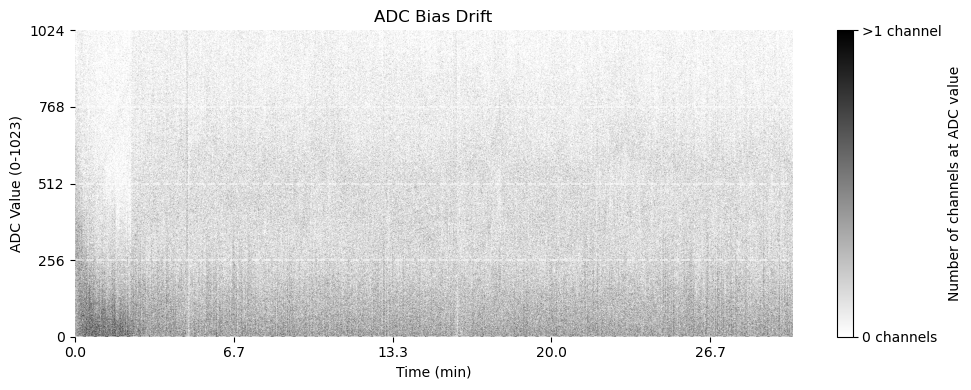

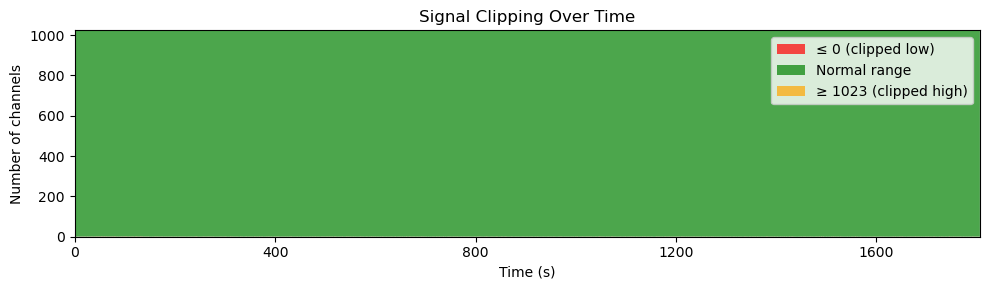

In [8]:


fig = plot_adc_bias.render_bias_heatmap(aggr_histogram)
fig.show()
fig = plot_adc_bias.render_clipping_plot(clipping_counts)
fig.show()


In [ ]:


fig = plot_adc_bias.render_bias_heatmap(aggr_histogram)
# fig = plot_adc_bias.render_clipping_plot(clipping_counts)
# fig = plot_adc_bias.render_bias_heatmap(aggr_histogram_tethered)
# fig = plot_adc_bias.render_clipping_plot(clipping_counts_tethered)
fig.show()

n_samples_logger
n_samples_tethered
session_dir_tethered
session_dir_logger
ampl_ids_logger
ampl_ids_tethered


In [37]:
n_samples_logger
n_samples_tethered
session_dir_tethered
session_dir_logger
ampl_ids_logger
ampl_ids_tethered

array([ 711,  871,  255,    3,  779,  771,  175,  565,  783,  447,  887,
        735,  551,   21,  979,   95,  259, 1019,  239, 1015,  623,  151,
        507,  847,  659,  215,  559,  983,  643,  207,  527,  855,  111,
        119,  419,  617,  391,  287,  109,  795,  243,   19,  839,  759,
        247,  471,  863,  679,  187,  575,  835,  619,  531,  851,  683,
        311,  211,  799,  719,  159,   71,  867,  171,  143,  811,  707,
        595,  423,  627,  943,  723,  371,   51,  843,  731,  403,  163,
        879,  727,  275,  127,  823,  715,  155,  415,  827,   31,  291,
        123,  775,  803,  199,  323,  859,  687,  347,  231,  995,  747,
        411,  755,  815,  579,  443,  131,  895,  703,  315,  223,  743,
        763,  499,  139,  791,   27,  267,  167,  891,  535,  387,  651,
        639,  455,  195,  787,  467,  583,  563,  251,  307,  183,  675,
        751,  431,  227,  647,  379,  567,  631,  523,  435,  135,   17,
        283,  399,  179,  695,  327,  667,  367,  6

Calculating RMS noise from 20 chunks...
[[  844   837   844 ...   774   756   730]
 [ -472  -491  -478 ...  -422  -441  -453]
 [-3222 -3222 -3222 ... -3222 -3222 -3222]
 ...
 [ -610  -604  -610 ...  -786  -774  -786]
 [  346   359   359 ...   -38   -38   -57]
 [ -302  -290  -283 ...  -548  -560  -566]]
(738, 20000)
Processed chunk 1/20[[-189 -208 -195 ...  -88  -88  -94]
 [-478 -478 -484 ... -384 -371 -384]
 [-434 -434 -422 ... -384 -378 -371]
 ...
 [ -13  -31  -38 ...   44   31   57]
 [-516 -510 -516 ... -346 -346 -328]
 [-378 -390 -409 ... -176 -176 -176]]
(738, 20000)
Processed chunk 2/20[[  422   422   441 ...   296   302   296]
 [ -630  -642  -636 ...  -824  -831  -824]
 [-1315 -1315 -1315 ... -1184 -1184 -1177]
 ...
 [ -189  -182  -182 ...  -359  -359  -346]
 [ -384  -378  -384 ...  -226  -226  -252]
 [ -478  -478  -472 ...  -542  -535  -548]]
(738, 20000)
Processed chunk 3/20[[   88   101   113 ...   226   239   239]
 [ -982  -969  -956 ... -1001 -1001 -1007]
 [-1315 -1303 -1303

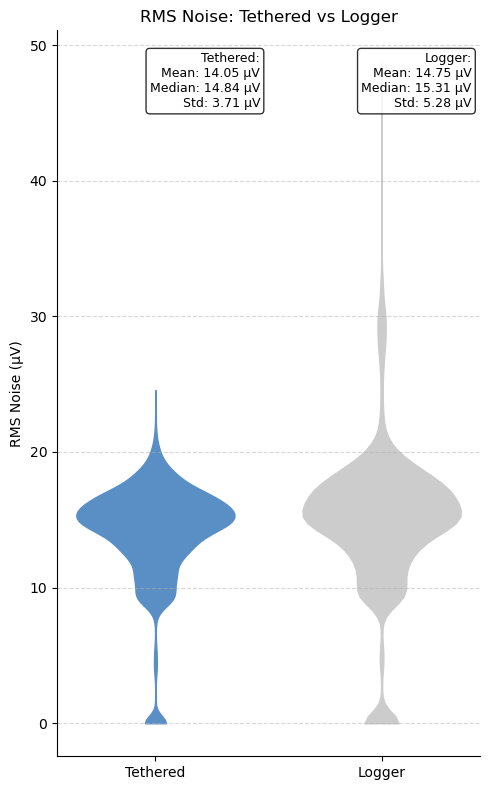

In [38]:
# Calculate RMS for both sessions with 20 chunks
rms_per_channel_tethered, rms_all_chunks_tethered = plot_adc_bias.calculate_rms_noise(
    session_dir_tethered, n_samples_tethered, ampl_ids=ampl_ids_tethered, n_chunks=20
)

rms_per_channel_logger, rms_all_chunks_logger = plot_adc_bias.calculate_rms_noise(
    session_dir_logger, n_samples_logger, ampl_ids=ampl_ids_logger, n_chunks=20
)

# Plot both sessions side by side
fig = plot_adc_bias.render_rms_violin(
    rms_all_chunks_tethered, rms_all_chunks_logger,
    color1='#5A8FC6', color2='#CCCCCC',
    label1='Tethered', label2='Logger',
    title='RMS Noise: Tethered vs Logger'
)
fig.show()

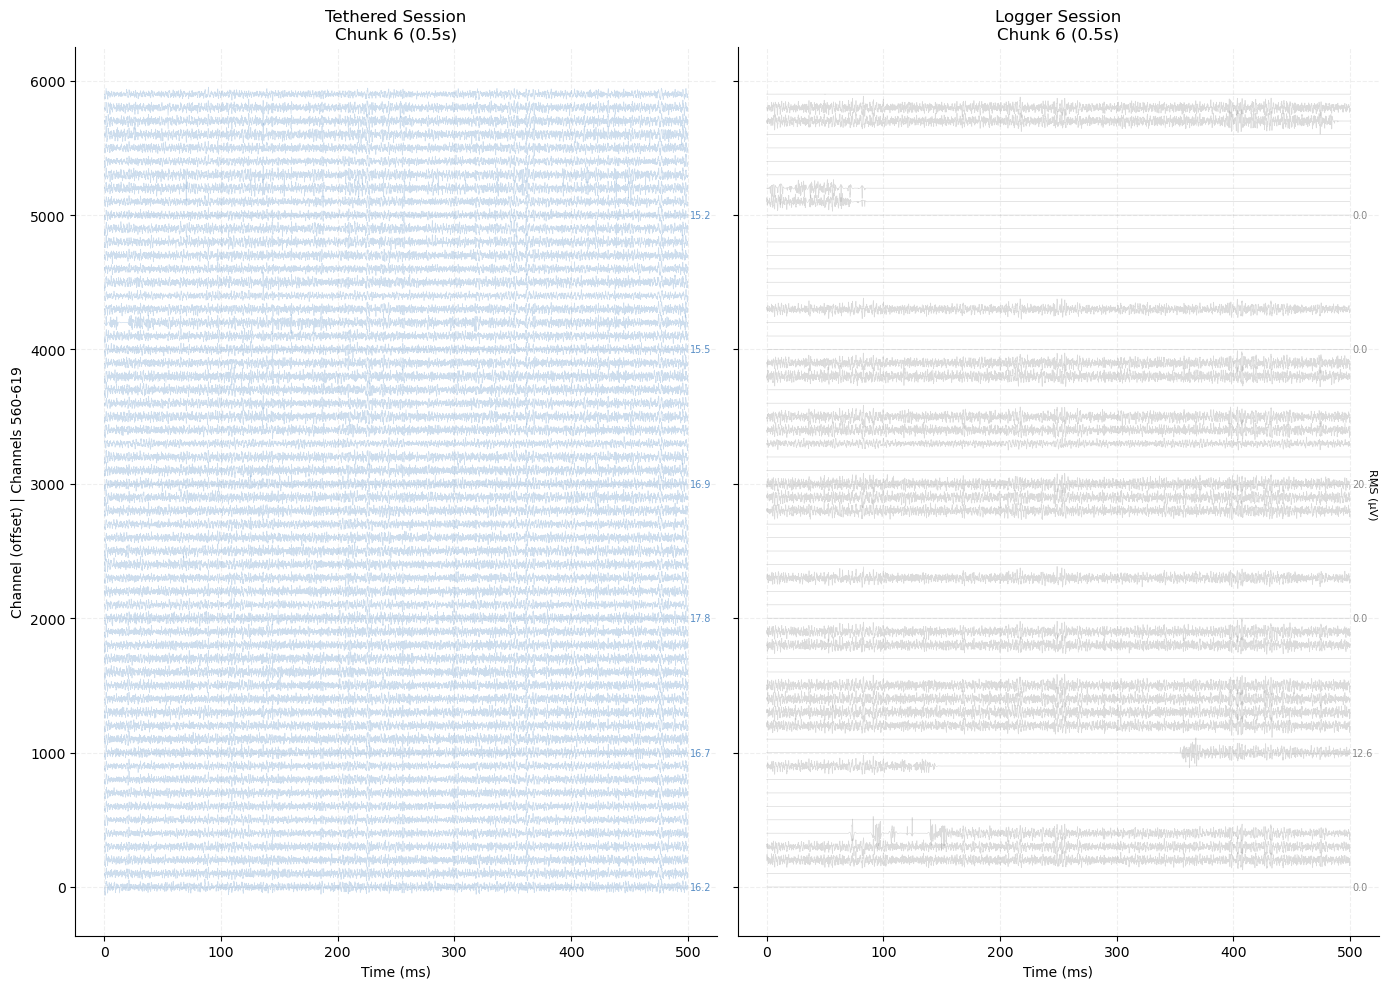

In [52]:
fig = plot_adc_bias.render_channel_stack_comparison(
    session_dir_tethered, session_dir_logger,
    n_samples_tethered, n_samples_logger,
    ampl_ids_tethered, ampl_ids_logger,
    chunk_idx=6, start_channel=560, n_channels=60
)
fig.show()